# CTR-GCN HPO Results Analysis

For each fold, selects the best-validated hyperparameter config and evaluates it on the test set.  
Also computes the best average hyperparameter combo across all 5 folds.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120

# ── Locate CV root ──────────────────────────────────────────────────────────
# Jupyter's CWD is wherever you launched it, NOT the notebook folder.
# We search upward from CWD until we find runs/ctr_gcn_kfold_hpo, then
# fall back to the hardcoded absolute path.
_MARKER = Path('runs') / 'ctr_gcn_kfold_hpo'
_search = Path(os.getcwd()).resolve()
CV_ROOT = None
for _ in range(8):
    if (_search / _MARKER).exists():
        CV_ROOT = _search
        break
    _search = _search.parent

if CV_ROOT is None:
    # Hardcoded fallback — edit if the project moves
    CV_ROOT = Path(r'D:\Brad\School\UofT\Year4\CSC494_eng\aps490-capstone-kite\CV')

os.chdir(CV_ROOT)
RUNS_ROOT = CV_ROOT / 'runs' / 'ctr_gcn_kfold_hpo'

assert RUNS_ROOT.exists(), f'RUNS_ROOT not found: {RUNS_ROOT}'
run_dirs = [p for p in RUNS_ROOT.iterdir() if p.is_dir()]
print(f'CV_ROOT  : {CV_ROOT}')
print(f'RUNS_ROOT: {RUNS_ROOT}')
print(f'Run dirs : {len(run_dirs)}')

CV_ROOT  : D:\Brad\School\UofT\Year4\CSC494_eng\aps490-capstone-kite\CV
RUNS_ROOT: D:\Brad\School\UofT\Year4\CSC494_eng\aps490-capstone-kite\CV\runs\ctr_gcn_kfold_hpo
Run dirs : 120


## 1. Load all runs

In [2]:
records = []
histories = {}   # run_name -> list of epoch dicts

for run_dir in sorted(run_dirs):
    summary_path = run_dir / 'summary.json'
    config_path  = run_dir / 'run_config.json'
    if not summary_path.exists() or not config_path.exists():
        continue

    with open(summary_path) as f:
        summary = json.load(f)
    with open(config_path) as f:
        cfg = json.load(f)

    tc = cfg['train_config']
    run_name = cfg['run_name']
    fold = int(cfg['fold'])
    bs   = int(tc['batch_size'])
    lr   = float(tc['lr'])
    wd   = float(tc['weight_decay'])

    # Best val_balanced_acc across all epochs
    history = summary.get('history', [])
    histories[run_name] = history
    best_val_bal_acc = max((ep['val_balanced_acc'] for ep in history), default=float('nan'))
    best_val_epoch   = next(
        (ep['epoch'] for ep in history if ep['val_balanced_acc'] == best_val_bal_acc),
        None
    )
    total_epochs = len(history)

    # Test metrics (evaluated at best checkpoint)
    te = summary.get('final_test', {})

    records.append({
        'run_name'      : run_name,
        'fold'          : fold,
        'batch_size'    : bs,
        'lr'            : lr,
        'weight_decay'  : wd,
        'hparam_key'    : f'bs{bs}_lr{lr:.0e}_wd{wd:.0e}',
        'best_val_bal_acc' : best_val_bal_acc,
        'best_val_epoch'   : best_val_epoch,
        'total_epochs'     : total_epochs,
        'test_bal_acc'  : te.get('balanced_acc', float('nan')),
        'test_acc'      : te.get('acc',           float('nan')),
        'test_tp'       : te.get('tp',            float('nan')),
        'test_tn'       : te.get('tn',            float('nan')),
        'test_fp'       : te.get('fp',            float('nan')),
        'test_fn'       : te.get('fn',            float('nan')),
        'test_tpr_fail' : te.get('tpr_fail',      float('nan')),
        'test_tnr_pass' : te.get('tnr_pass',      float('nan')),
        'test_loss'     : te.get('loss',           float('nan')),
    })

df = pd.DataFrame(records)
print(f'Loaded {len(df)} runs across {df["fold"].nunique()} folds and {df["hparam_key"].nunique()} hparam combos')
df.head()

Loaded 120 runs across 5 folds and 24 hparam combos


,run_name,fold,batch_size,lr,weight_decay,hparam_key,best_val_bal_acc,best_val_epoch,total_epochs,test_bal_acc,test_acc,test_tp,test_tn,test_fp,test_fn,test_tpr_fail,test_tnr_pass,test_loss
0,fold0_bs16_lr1e-02_wd1e-04,0,16,0.0100,0.0001,bs16_lr1e-02_wd1e-04,0.9019,51,76,0.9085,0.9102,66.0000,157.0000,15.0000,7.0000,0.9041,0.9128,0.3088
1,fold0_bs16_lr1e-02_wd1e-05,0,16,0.0100,0.0000,bs16_lr1e-02_wd1e-05,0.8821,22,47,0.8659,0.8449,67.0000,140.0000,32.0000,6.0000,0.9178,0.8140,0.4112
2,fold0_bs16_lr1e-03_wd1e-04,0,16,0.0010,0.0001,bs16_lr1e-03_wd1e-04,0.8875,29,54,0.8636,0.8694,62.0000,151.0000,21.0000,11.0000,0.8493,0.8779,0.4263
3,fold0_bs16_lr1e-03_wd1e-05,0,16,0.0010,0.0000,bs16_lr1e-03_wd1e-05,0.8969,51,76,0.8916,0.9143,61.0000,163.0000,9.0000,12.0000,0.8356,0.9477,0.4583
4,fold0_bs16_lr1e-04_wd1e-04,0,16,0.0001,0.0001,bs16_lr1e-04_wd1e-04,0.8785,98,123,0.8055,0.7878,62.0000,131.0000,41.0000,11.0000,0.8493,0.7616,2.6413


## 2. Per-fold: select best-validated model

In [3]:
# For each fold, pick the run with the highest best_val_bal_acc
best_per_fold = (
    df.sort_values('best_val_bal_acc', ascending=False)
      .groupby('fold', sort=True)
      .first()
      .reset_index()
)

display_cols = ['fold', 'hparam_key', 'best_val_bal_acc', 'best_val_epoch', 'total_epochs',
                'test_bal_acc', 'test_acc', 'test_tpr_fail', 'test_tnr_pass',
                'test_tp', 'test_tn', 'test_fp', 'test_fn']
print('=== Best model per fold (selected by val_balanced_acc) ===')
display(best_per_fold[display_cols].style.format({
    'best_val_bal_acc': '{:.4f}',
    'test_bal_acc':     '{:.4f}',
    'test_acc':         '{:.4f}',
    'test_tpr_fail':    '{:.4f}',
    'test_tnr_pass':    '{:.4f}',
}).highlight_max(subset=['test_bal_acc'], color='lightgreen'))

=== Best model per fold (selected by val_balanced_acc) ===


,fold,hparam_key,best_val_bal_acc,best_val_epoch,total_epochs,test_bal_acc,test_acc,test_tpr_fail,test_tnr_pass,test_tp,test_tn,test_fp,test_fn
0,0,bs64_lr1e-02_wd1e-05,0.9026,46,71,0.9066,0.9020,0.9178,0.8953,67.000000,154.000000,18.000000,6.000000
1,1,bs32_lr1e-02_wd1e-05,0.9084,81,106,0.8789,0.8877,0.8621,0.8957,75.000000,249.000000,29.000000,12.000000
2,2,bs16_lr1e-02_wd1e-05,0.9192,17,42,0.8024,0.8725,0.6667,0.9381,24.000000,106.000000,7.000000,12.000000
3,3,bs16_lr1e-02_wd1e-04,0.9334,19,44,0.8528,0.8085,0.9302,0.7753,80.000000,245.000000,71.000000,6.000000
4,4,bs32_lr1e-02_wd1e-04,0.9346,56,81,0.9187,0.9459,0.8661,0.9714,97.000000,340.000000,10.000000,15.000000


In [4]:
# Summary statistics across folds (using the per-fold best models)
summary_stats = best_per_fold[['test_bal_acc','test_acc','test_tpr_fail','test_tnr_pass']].agg(['mean','std','min','max'])
print('=== Cross-fold summary (best-per-fold test metrics) ===')
display(summary_stats)

=== Cross-fold summary (best-per-fold test metrics) ===


,test_bal_acc,test_acc,test_tpr_fail,test_tnr_pass
mean,0.8719,0.8833,0.8486,0.8952
std,0.0465,0.0500,0.1061,0.0742
min,0.8024,0.8085,0.6667,0.7753
max,0.9187,0.9459,0.9302,0.9714


## 3. Per-hparam aggregation across folds

In [5]:
agg = (
    df.groupby(['batch_size', 'lr', 'weight_decay', 'hparam_key'])
      .agg(
          n_folds              = ('fold',             'count'),
          val_bal_acc_mean     = ('best_val_bal_acc', 'mean'),
          val_bal_acc_std      = ('best_val_bal_acc', 'std'),
          test_bal_acc_mean    = ('test_bal_acc',     'mean'),
          test_bal_acc_std     = ('test_bal_acc',     'std'),
          test_tpr_fail_mean   = ('test_tpr_fail',    'mean'),
          test_tnr_pass_mean   = ('test_tnr_pass',    'mean'),
          test_acc_mean        = ('test_acc',         'mean'),
          avg_epochs           = ('total_epochs',     'mean'),
      )
      .reset_index()
      .sort_values('val_bal_acc_mean', ascending=False)
)

print('=== All hparam combos ranked by mean val_balanced_acc (across 5 folds) ===')
display(agg.style.format({
    'val_bal_acc_mean':   '{:.4f}',
    'val_bal_acc_std':    '{:.4f}',
    'test_bal_acc_mean':  '{:.4f}',
    'test_bal_acc_std':   '{:.4f}',
    'test_tpr_fail_mean': '{:.4f}',
    'test_tnr_pass_mean': '{:.4f}',
    'test_acc_mean':      '{:.4f}',
    'avg_epochs':         '{:.1f}',
    'lr':                 '{:.0e}',
    'weight_decay':       '{:.0e}',
}).highlight_max(subset=['val_bal_acc_mean', 'test_bal_acc_mean'], color='lightgreen'))

best_combo = agg.iloc[0]
print(f"\n>>> Best hparam combo: {best_combo['hparam_key']}")
print(f"    val_bal_acc  = {best_combo['val_bal_acc_mean']:.4f} ± {best_combo['val_bal_acc_std']:.4f}")
print(f"    test_bal_acc = {best_combo['test_bal_acc_mean']:.4f} ± {best_combo['test_bal_acc_std']:.4f}")

=== All hparam combos ranked by mean val_balanced_acc (across 5 folds) ===


,batch_size,lr,weight_decay,hparam_key,n_folds,val_bal_acc_mean,val_bal_acc_std,test_bal_acc_mean,test_bal_acc_std,test_tpr_fail_mean,test_tnr_pass_mean,test_acc_mean,avg_epochs
14,32,1e-02,1e-05,bs32_lr1e-02_wd1e-05,5,0.9047,0.0109,0.8517,0.0472,0.7886,0.9147,0.8822,71.0
15,32,1e-02,1e-04,bs32_lr1e-02_wd1e-04,5,0.9041,0.0202,0.8603,0.0539,0.8239,0.8967,0.8778,62.0
7,16,1e-02,1e-04,bs16_lr1e-02_wd1e-04,5,0.9019,0.0243,0.8622,0.0359,0.8320,0.8924,0.8768,61.0
6,16,1e-02,1e-05,bs16_lr1e-02_wd1e-05,5,0.8977,0.0200,0.8482,0.0391,0.8276,0.8688,0.8591,41.0
23,64,1e-02,1e-04,bs64_lr1e-02_wd1e-04,5,0.8921,0.0085,0.8300,0.0738,0.8078,0.8522,0.8389,62.0
4,16,1e-03,1e-05,bs16_lr1e-03_wd1e-05,5,0.8906,0.0232,0.8419,0.0571,0.8161,0.8677,0.8545,73.6
5,16,1e-03,1e-04,bs16_lr1e-03_wd1e-04,5,0.8889,0.0180,0.8516,0.0458,0.7870,0.9162,0.8857,56.4
12,32,1e-03,1e-05,bs32_lr1e-03_wd1e-05,5,0.8847,0.0296,0.8384,0.0500,0.7762,0.9005,0.8712,54.4
13,32,1e-03,1e-04,bs32_lr1e-03_wd1e-04,5,0.8793,0.0189,0.8350,0.0464,0.7908,0.8792,0.8603,67.2
22,64,1e-02,1e-05,bs64_lr1e-02_wd1e-05,5,0.8760,0.0228,0.8463,0.0592,0.8123,0.8803,0.8641,63.8



>>> Best hparam combo: bs32_lr1e-02_wd1e-05
    val_bal_acc  = 0.9047 ± 0.0109
    test_bal_acc = 0.8517 ± 0.0472


## 4. Visualizations

### 4a. Test balanced accuracy per fold (best selected model)

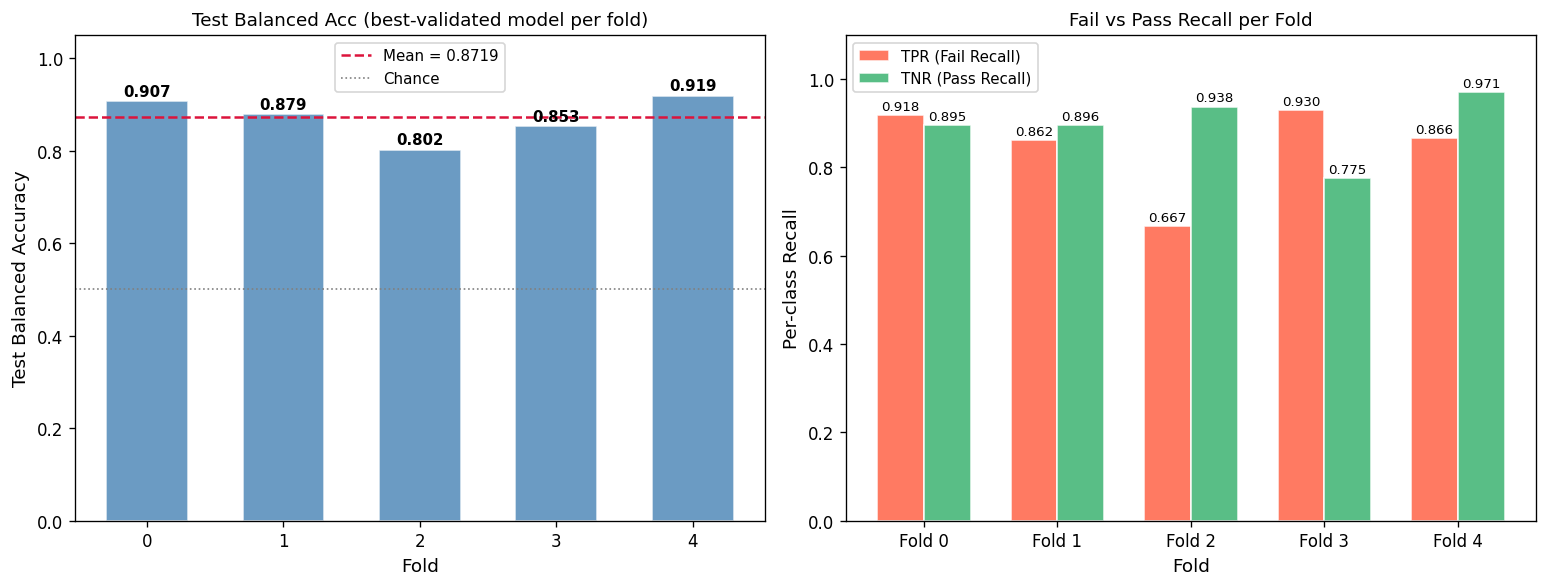

Saved: results_per_fold.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

folds = best_per_fold['fold'].values
test_bal = best_per_fold['test_bal_acc'].values
test_tpr = best_per_fold['test_tpr_fail'].values
test_tnr = best_per_fold['test_tnr_pass'].values
mean_bal = test_bal.mean()

# Left: balanced acc
ax = axes[0]
bars = ax.bar(folds, test_bal, color='steelblue', alpha=0.8, edgecolor='white', width=0.6)
ax.axhline(mean_bal, color='crimson', linestyle='--', linewidth=1.5, label=f'Mean = {mean_bal:.4f}')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.0, label='Chance')
for bar, val in zip(bars, test_bal):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel('Fold', fontsize=11)
ax.set_ylabel('Test Balanced Accuracy', fontsize=11)
ax.set_title('Test Balanced Acc (best-validated model per fold)', fontsize=11)
ax.set_xticks(folds)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

# Right: TPR (fail recall) vs TNR (pass recall)
ax2 = axes[1]
x = np.arange(len(folds))
w = 0.35
b1 = ax2.bar(x - w/2, test_tpr, w, label='TPR (Fail Recall)', color='tomato', alpha=0.85, edgecolor='white')
b2 = ax2.bar(x + w/2, test_tnr, w, label='TNR (Pass Recall)', color='mediumseagreen', alpha=0.85, edgecolor='white')
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax2.set_xlabel('Fold', fontsize=11)
ax2.set_ylabel('Per-class Recall', fontsize=11)
ax2.set_title('Fail vs Pass Recall per Fold', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels([f'Fold {f}' for f in folds])
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('results_per_fold.png', bbox_inches='tight')
plt.show()
print('Saved: results_per_fold.png')

### 4b. Confusion matrices for each fold's best model

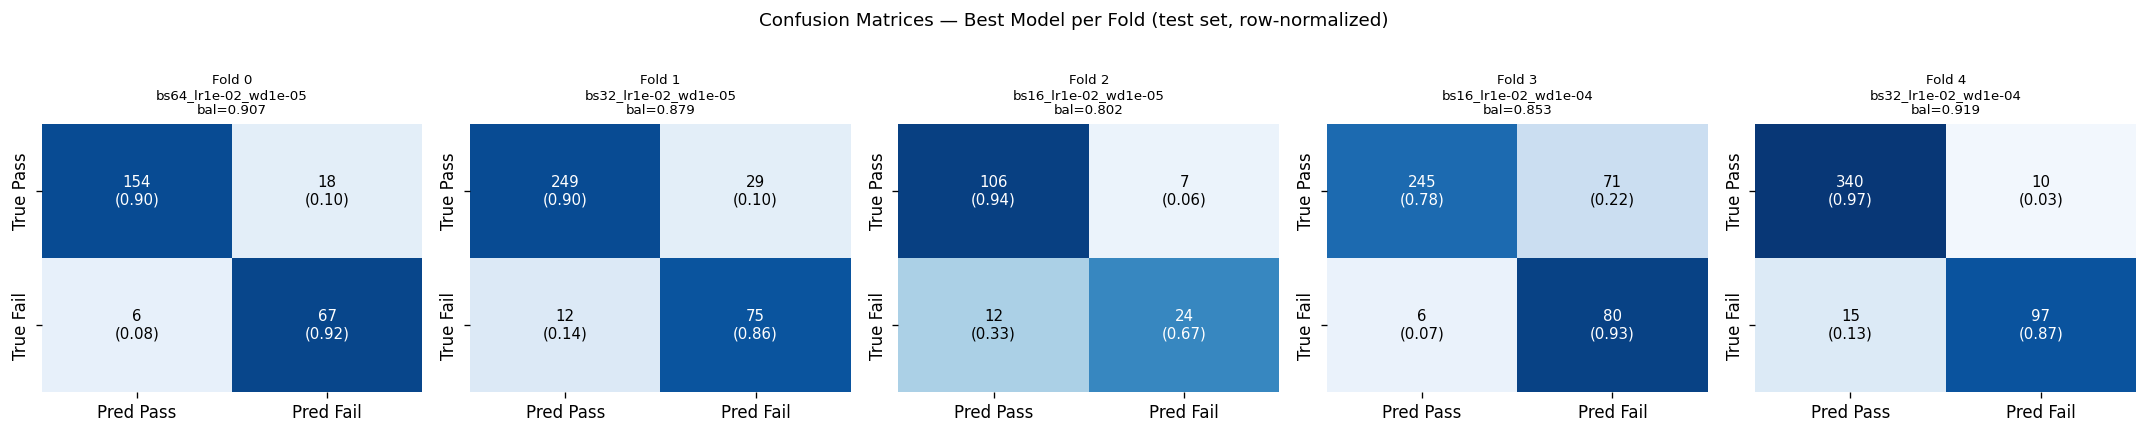

Saved: confusion_matrices.png


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

for ax, (_, row) in zip(axes, best_per_fold.iterrows()):
    tp, tn, fp, fn = int(row['test_tp']), int(row['test_tn']), int(row['test_fp']), int(row['test_fn'])
    cm = np.array([[tn, fp], [fn, tp]])
    
    # Normalize by row (true class)
    cm_norm = cm.astype(float)
    for i in range(2):
        row_sum = cm[i].sum()
        if row_sum > 0:
            cm_norm[i] = cm[i] / row_sum

    sns.heatmap(cm_norm, annot=False, fmt='', cmap='Blues', ax=ax,
                vmin=0, vmax=1, cbar=False,
                xticklabels=['Pred Pass', 'Pred Fail'],
                yticklabels=['True Pass', 'True Fail'])

    # Annotate cells with count (rate)
    labels = [[f'{tn}\n({cm_norm[0,0]:.2f})', f'{fp}\n({cm_norm[0,1]:.2f})'],
              [f'{fn}\n({cm_norm[1,0]:.2f})', f'{tp}\n({cm_norm[1,1]:.2f})']]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.5, labels[i][j],
                    ha='center', va='center', fontsize=9,
                    color='white' if cm_norm[i, j] > 0.6 else 'black')

    bal = row['test_bal_acc']
    fold_n = int(row['fold'])
    hk = row['hparam_key']
    ax.set_title(f'Fold {fold_n}\n{hk}\nbal={bal:.3f}', fontsize=8)

plt.suptitle('Confusion Matrices — Best Model per Fold (test set, row-normalized)', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

### 4c. Training curves for the best run in each fold

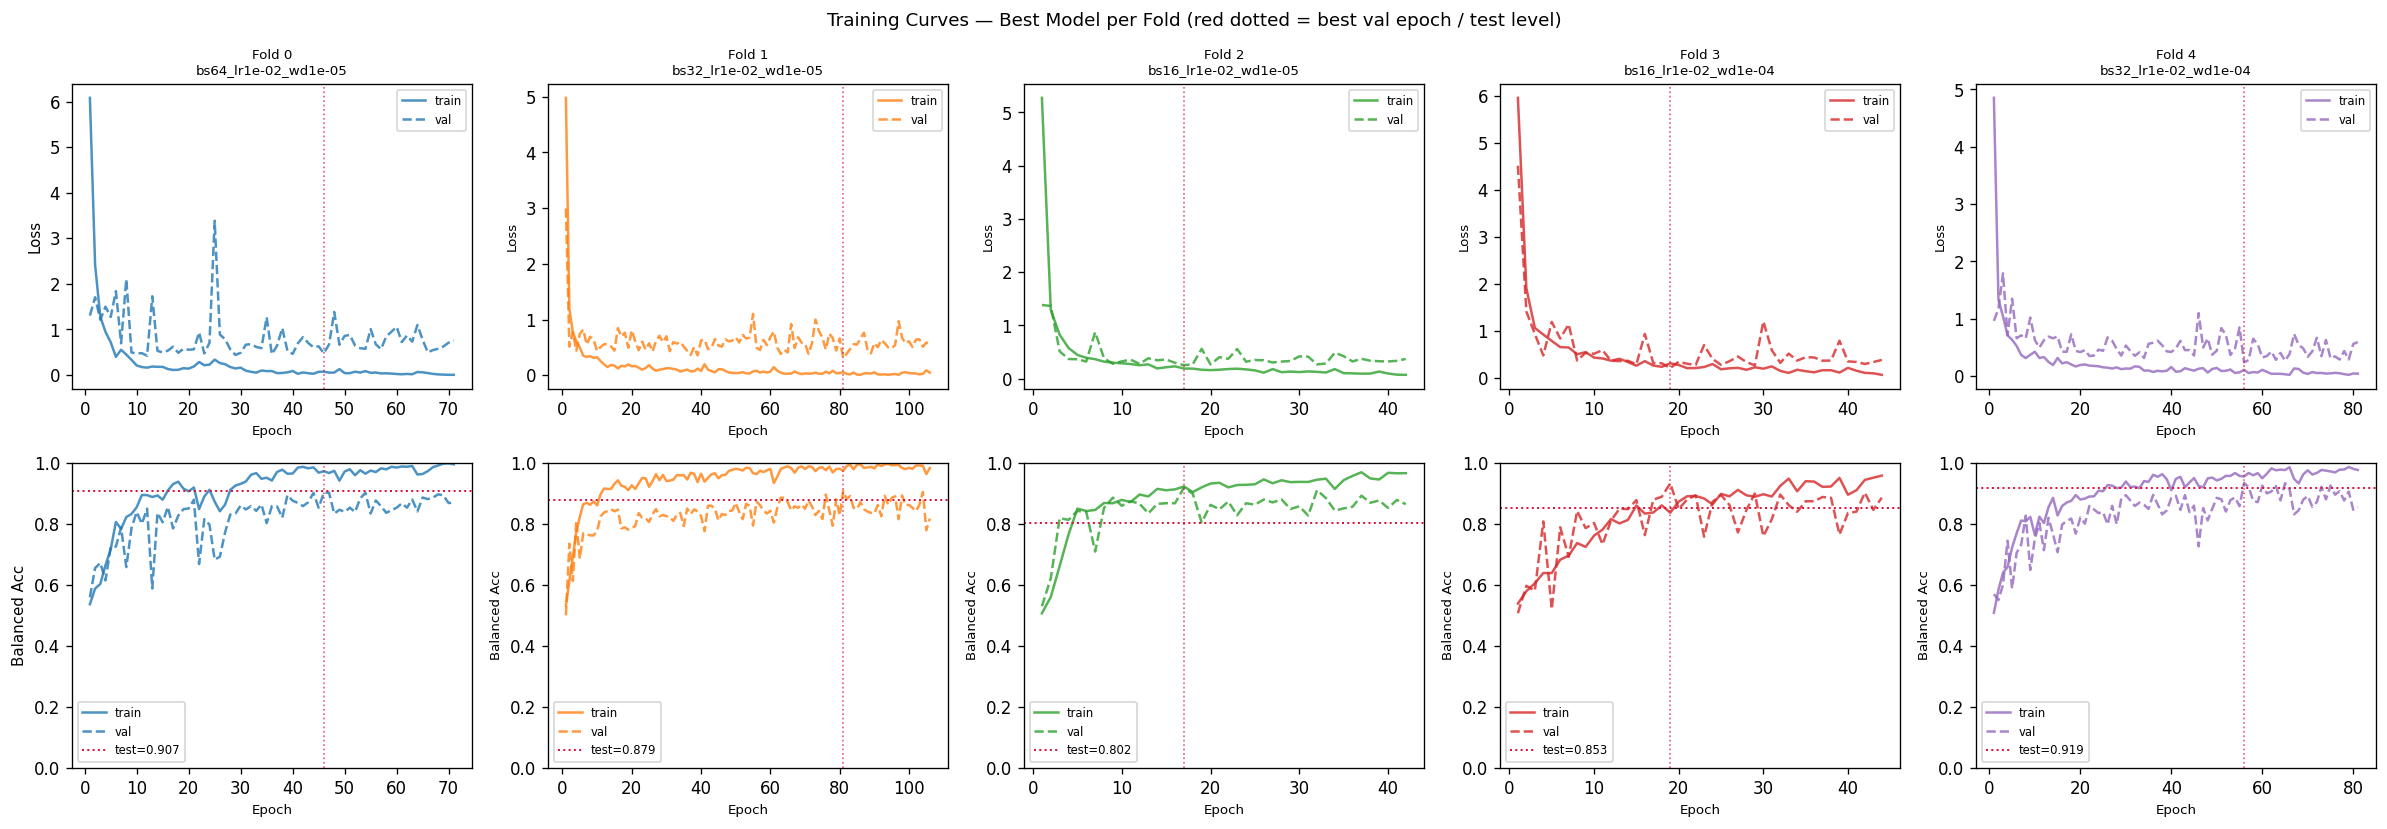

Saved: training_curves.png


In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharex=False)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for col_idx, (_, row) in enumerate(best_per_fold.iterrows()):
    run_name = row['run_name']
    hist = histories.get(run_name, [])
    if not hist:
        continue

    epochs       = [ep['epoch'] for ep in hist]
    train_loss   = [ep['train_loss'] for ep in hist]
    val_loss     = [ep['val_loss'] for ep in hist]
    train_bal    = [ep['train_balanced_acc'] for ep in hist]
    val_bal      = [ep['val_balanced_acc'] for ep in hist]

    best_ep = row['best_val_epoch']
    fold_n  = int(row['fold'])
    hk      = row['hparam_key']
    c       = colors[col_idx % len(colors)]

    # Loss
    ax_loss = axes[0, col_idx]
    ax_loss.plot(epochs, train_loss, label='train', alpha=0.8, color=c)
    ax_loss.plot(epochs, val_loss,   label='val',   alpha=0.8, color=c, linestyle='--')
    if best_ep:
        ax_loss.axvline(best_ep, color='crimson', linestyle=':', linewidth=1, alpha=0.7)
    ax_loss.set_title(f'Fold {fold_n}\n{hk}', fontsize=8)
    ax_loss.set_xlabel('Epoch', fontsize=8)
    ax_loss.set_ylabel('Loss', fontsize=8)
    ax_loss.legend(fontsize=7)

    # Balanced accuracy
    ax_acc = axes[1, col_idx]
    ax_acc.plot(epochs, train_bal, label='train', alpha=0.8, color=c)
    ax_acc.plot(epochs, val_bal,   label='val',   alpha=0.8, color=c, linestyle='--')
    ax_acc.axhline(row['test_bal_acc'], color='crimson', linestyle=':', linewidth=1.2,
                   label=f'test={row["test_bal_acc"]:.3f}')
    if best_ep:
        ax_acc.axvline(best_ep, color='crimson', linestyle=':', linewidth=1, alpha=0.7)
    ax_acc.set_xlabel('Epoch', fontsize=8)
    ax_acc.set_ylabel('Balanced Acc', fontsize=8)
    ax_acc.set_ylim(0, 1)
    ax_acc.legend(fontsize=7)

axes[0, 0].set_ylabel('Loss', fontsize=9)
axes[1, 0].set_ylabel('Balanced Acc', fontsize=9)
fig.suptitle('Training Curves — Best Model per Fold (red dotted = best val epoch / test level)', fontsize=11)
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

### 4d. Heatmaps: mean val & test balanced acc by (LR × batch size)

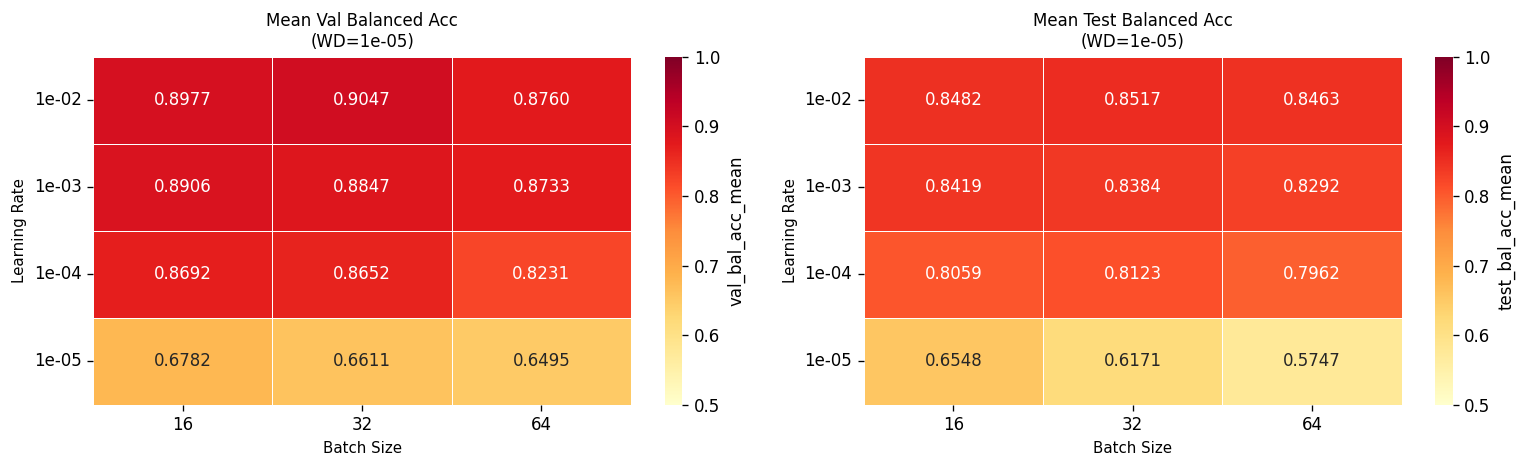

Saved: heatmap_wd1e-05.png


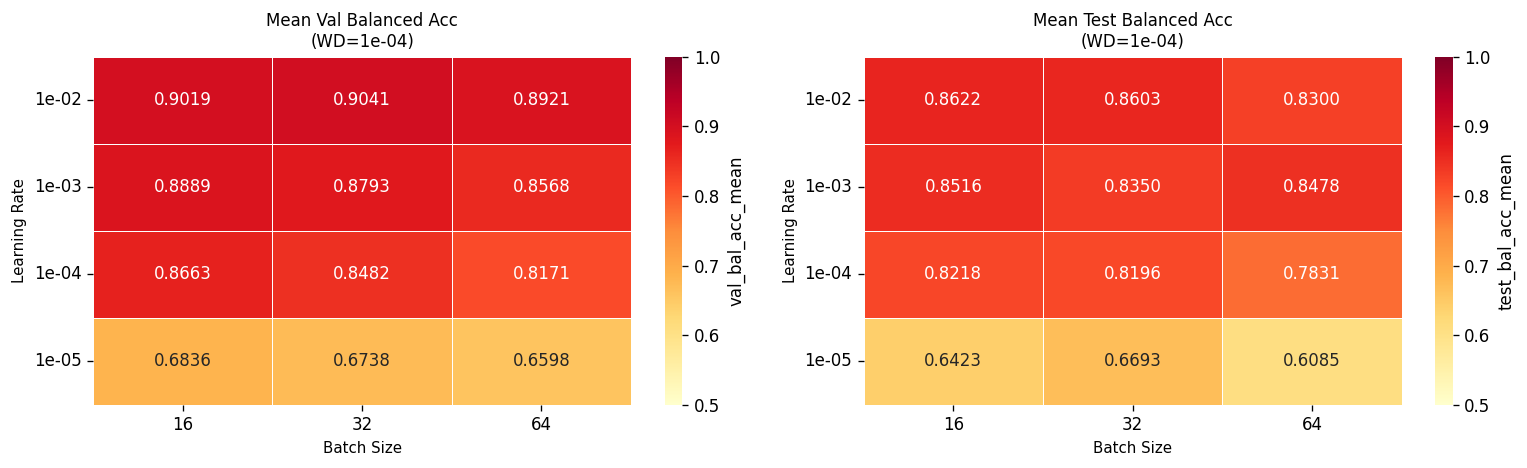

Saved: heatmap_wd1e-04.png


In [9]:
for wd_val in sorted(df['weight_decay'].unique()):
    subset = agg[agg['weight_decay'] == wd_val]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, metric, title in [
        (axes[0], 'val_bal_acc_mean',  'Mean Val Balanced Acc'),
        (axes[1], 'test_bal_acc_mean', 'Mean Test Balanced Acc'),
    ]:
        pivot = subset.pivot(index='lr', columns='batch_size', values=metric)
        pivot = pivot.sort_index(ascending=False)
        sns.heatmap(
            pivot, ax=ax, annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0.5, vmax=1.0, cbar_kws={'label': metric},
            linewidths=0.5
        )
        ax.set_title(f'{title}\n(WD={wd_val:.0e})', fontsize=10)
        ax.set_xlabel('Batch Size', fontsize=9)
        ax.set_ylabel('Learning Rate', fontsize=9)
        ax.set_yticklabels([f'{v:.0e}' for v in pivot.index], rotation=0)

    plt.tight_layout()
    fname = f'heatmap_wd{wd_val:.0e}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

### 4e. Top-10 hparam combos: val vs test balanced acc

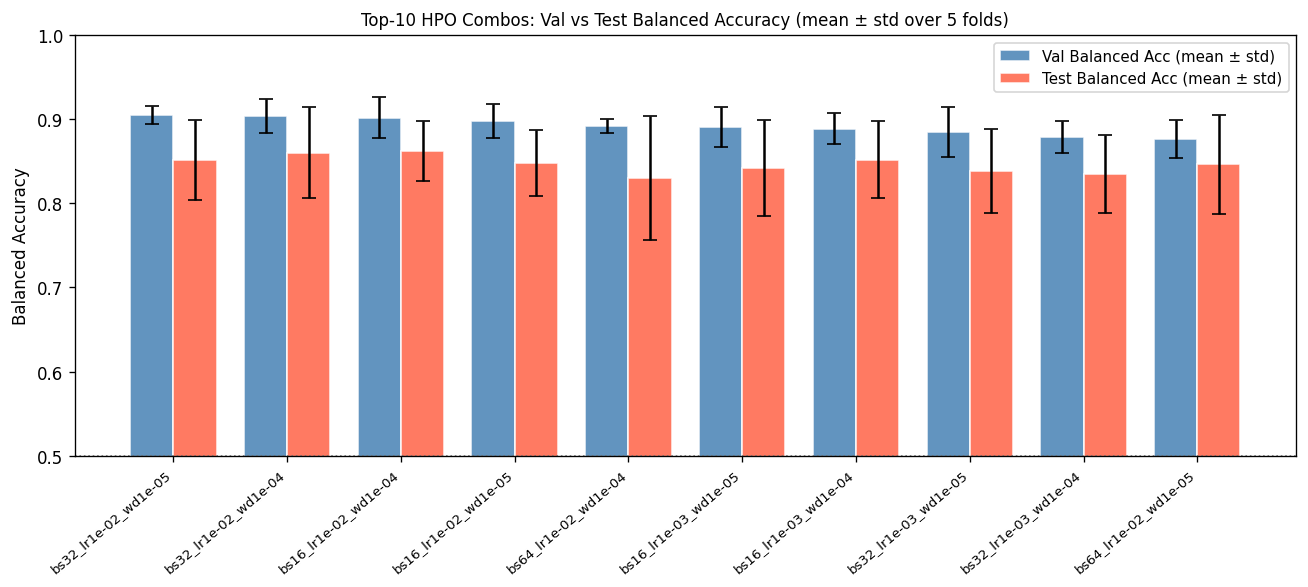

Saved: top10_hpo.png


In [10]:
top10 = agg.head(10).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(top10))
w = 0.38

b1 = ax.bar(x - w/2, top10['val_bal_acc_mean'], w, yerr=top10['val_bal_acc_std'],
            label='Val Balanced Acc (mean ± std)', color='steelblue', alpha=0.85,
            capsize=4, edgecolor='white')
b2 = ax.bar(x + w/2, top10['test_bal_acc_mean'], w, yerr=top10['test_bal_acc_std'],
            label='Test Balanced Acc (mean ± std)', color='tomato', alpha=0.85,
            capsize=4, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(top10['hparam_key'], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Balanced Accuracy', fontsize=10)
ax.set_title('Top-10 HPO Combos: Val vs Test Balanced Accuracy (mean ± std over 5 folds)', fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('top10_hpo.png', bbox_inches='tight')
plt.show()
print('Saved: top10_hpo.png')

### 4f. Full ranking table (all combos, val and test)

In [11]:
ranking_display = agg[[
    'hparam_key', 'batch_size', 'lr', 'weight_decay',
    'val_bal_acc_mean', 'val_bal_acc_std',
    'test_bal_acc_mean', 'test_bal_acc_std',
    'test_tpr_fail_mean', 'test_tnr_pass_mean',
    'test_acc_mean', 'avg_epochs',
]].copy()
ranking_display.index = range(1, len(ranking_display) + 1)
ranking_display.index.name = 'rank'

print('=== Full HPO Ranking (by mean val balanced acc) ===')
display(ranking_display.style.format({
    'lr':                  '{:.0e}',
    'weight_decay':        '{:.0e}',
    'val_bal_acc_mean':    '{:.4f}',
    'val_bal_acc_std':     '{:.4f}',
    'test_bal_acc_mean':   '{:.4f}',
    'test_bal_acc_std':    '{:.4f}',
    'test_tpr_fail_mean':  '{:.4f}',
    'test_tnr_pass_mean':  '{:.4f}',
    'test_acc_mean':       '{:.4f}',
    'avg_epochs':          '{:.1f}',
}).highlight_max(subset=['val_bal_acc_mean', 'test_bal_acc_mean'], color='lightgreen')
  .highlight_min(subset=['val_bal_acc_mean', 'test_bal_acc_mean'], color='#ffcccc'))

=== Full HPO Ranking (by mean val balanced acc) ===


,hparam_key,batch_size,lr,weight_decay,val_bal_acc_mean,val_bal_acc_std,test_bal_acc_mean,test_bal_acc_std,test_tpr_fail_mean,test_tnr_pass_mean,test_acc_mean,avg_epochs
rank,,,,,,,,,,,,
1,bs32_lr1e-02_wd1e-05,32,1e-02,1e-05,0.9047,0.0109,0.8517,0.0472,0.7886,0.9147,0.8822,71.0
2,bs32_lr1e-02_wd1e-04,32,1e-02,1e-04,0.9041,0.0202,0.8603,0.0539,0.8239,0.8967,0.8778,62.0
3,bs16_lr1e-02_wd1e-04,16,1e-02,1e-04,0.9019,0.0243,0.8622,0.0359,0.8320,0.8924,0.8768,61.0
4,bs16_lr1e-02_wd1e-05,16,1e-02,1e-05,0.8977,0.0200,0.8482,0.0391,0.8276,0.8688,0.8591,41.0
5,bs64_lr1e-02_wd1e-04,64,1e-02,1e-04,0.8921,0.0085,0.8300,0.0738,0.8078,0.8522,0.8389,62.0
6,bs16_lr1e-03_wd1e-05,16,1e-03,1e-05,0.8906,0.0232,0.8419,0.0571,0.8161,0.8677,0.8545,73.6
7,bs16_lr1e-03_wd1e-04,16,1e-03,1e-04,0.8889,0.0180,0.8516,0.0458,0.7870,0.9162,0.8857,56.4
8,bs32_lr1e-03_wd1e-05,32,1e-03,1e-05,0.8847,0.0296,0.8384,0.0500,0.7762,0.9005,0.8712,54.4
9,bs32_lr1e-03_wd1e-04,32,1e-03,1e-04,0.8793,0.0189,0.8350,0.0464,0.7908,0.8792,0.8603,67.2


## 5. Final summary

In [12]:
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f'\nTotal runs: {len(df)} ({df["fold"].nunique()} folds × {df["hparam_key"].nunique()} hparam combos)')

print('\n--- Per-fold best model (test set performance) ---')
for _, row in best_per_fold.iterrows():
    print(
        f"  Fold {int(row['fold'])}: {row['hparam_key']:<28}"
        f"  val_bal={row['best_val_bal_acc']:.4f} @ ep{int(row['best_val_epoch'] or 0)}/{int(row['total_epochs'])}"
        f"  → test_bal={row['test_bal_acc']:.4f} "
        f"(TPR={row['test_tpr_fail']:.3f}, TNR={row['test_tnr_pass']:.3f})"
    )

mean_test = best_per_fold['test_bal_acc'].mean()
std_test  = best_per_fold['test_bal_acc'].std()
print(f'\n  Average test balanced acc (best-per-fold): {mean_test:.4f} ± {std_test:.4f}')

best_combo = agg.iloc[0]
print('\n--- Best hparam combo across all folds ---')
print(f"  Config : {best_combo['hparam_key']}")
print(f"  Val    : {best_combo['val_bal_acc_mean']:.4f} ± {best_combo['val_bal_acc_std']:.4f}")
print(f"  Test   : {best_combo['test_bal_acc_mean']:.4f} ± {best_combo['test_bal_acc_std']:.4f}")
print(f"  TPR    : {best_combo['test_tpr_fail_mean']:.4f}")
print(f"  TNR    : {best_combo['test_tnr_pass_mean']:.4f}")
print(f"  Avg epochs trained: {best_combo['avg_epochs']:.1f}")

FINAL SUMMARY

Total runs: 120 (5 folds × 24 hparam combos)

--- Per-fold best model (test set performance) ---
  Fold 0: bs64_lr1e-02_wd1e-05          val_bal=0.9026 @ ep46/71  → test_bal=0.9066 (TPR=0.918, TNR=0.895)
  Fold 1: bs32_lr1e-02_wd1e-05          val_bal=0.9084 @ ep81/106  → test_bal=0.8789 (TPR=0.862, TNR=0.896)
  Fold 2: bs16_lr1e-02_wd1e-05          val_bal=0.9192 @ ep17/42  → test_bal=0.8024 (TPR=0.667, TNR=0.938)
  Fold 3: bs16_lr1e-02_wd1e-04          val_bal=0.9334 @ ep19/44  → test_bal=0.8528 (TPR=0.930, TNR=0.775)
  Fold 4: bs32_lr1e-02_wd1e-04          val_bal=0.9346 @ ep56/81  → test_bal=0.9187 (TPR=0.866, TNR=0.971)

  Average test balanced acc (best-per-fold): 0.8719 ± 0.0465

--- Best hparam combo across all folds ---
  Config : bs32_lr1e-02_wd1e-05
  Val    : 0.9047 ± 0.0109
  Test   : 0.8517 ± 0.0472
  TPR    : 0.7886
  TNR    : 0.9147
  Avg epochs trained: 71.0
